<a href="https://colab.research.google.com/github/Mrinal0044/DEEP-LEARNING/blob/main/cat_vs_dog_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset


Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
 99% 782M/788M [00:03<00:00, 112MB/s] 
100% 788M/788M [00:03<00:00, 208MB/s]


In [6]:
!unzip microsoft-catsvsdogs-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/550.jpg   
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  

In [7]:
import os
os.listdir('/content')


['.config',
 'PetImages',
 'kaggle.json',
 'MSR-LA - 3467.docx',
 'microsoft-catsvsdogs-dataset.zip',
 'readme[1].txt',
 'sample_data']

In [8]:
import os

cat_path = "/content/PetImages/Cat"
dog_path = "/content/PetImages/Dog"

print("Cats:", len(os.listdir(cat_path)))
print("Dogs:", len(os.listdir(dog_path)))


Cats: 12501
Dogs: 12501


In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [10]:
import os
from PIL import Image

data_dir = "/content/PetImages"

bad = 0
for category in ["Cat", "Dog"]:
    folder = os.path.join(data_dir, category)
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            img = Image.open(path)
            img = img.convert("RGB")
            img.verify()
        except:
            os.remove(path)
            bad += 1

print("Removed bad images:", bad)


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removed bad images: 4


In [11]:
import shutil, random

source_dir = "/content/PetImages"
base_dir = "/content/dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

for folder in [train_dir, test_dir]:
    for category in ["Cat", "Dog"]:
        os.makedirs(os.path.join(folder, category), exist_ok=True)

split = 0.8

for category in ["Cat", "Dog"]:
    src = os.path.join(source_dir, category)
    images = os.listdir(src)
    random.shuffle(images)

    cut = int(len(images) * split)
    train_imgs = images[:cut]
    test_imgs = images[cut:]

    for img in train_imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(train_dir, category, img))

    for img in test_imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(test_dir, category, img))

print("Train/Test created ✅")


Train/Test created ✅


In [12]:
import tensorflow as tf

IMG = 224
BATCH = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/train",
    image_size=(IMG, IMG),
    batch_size=BATCH
).apply(tf.data.experimental.ignore_errors())

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset/test",
    image_size=(IMG, IMG),
    batch_size=BATCH,
    shuffle=False
).apply(tf.data.experimental.ignore_errors())


Found 19998 files belonging to 2 classes.


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Found 5000 files belonging to 2 classes.


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (x/255.0, y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (x/255.0, y)).prefetch(AUTOTUNE)


In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)


Epoch 1/10
    619/Unknown 45s 59ms/step - accuracy: 0.5767 - loss: 0.7039

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


619/619 ━━━━━━━━━━━━━━━━━━━━ 53s 72ms/step - accuracy: 0.5768 - loss: 0.7038 - val_accuracy: 0.6924 - val_loss: 0.5686
Epoch 2/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.7228 - loss: 0.5470 - val_accuracy: 0.7772 - val_loss: 0.4813
Epoch 3/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7862 - loss: 0.4566 - val_accuracy: 0.7806 - val_loss: 0.4621
Epoch 4/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.8277 - loss: 0.3877 - val_accuracy: 0.8045 - val_loss: 0.4459
Epoch 5/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 39s 64ms/step - accuracy: 0.8647 - loss: 0.3088 - val_accuracy: 0.8074 - val_loss: 0.5162
Epoch 6/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9002 - loss: 0.2362 - val_accuracy: 0.7969 - val_loss: 0.5667
Epoch 7/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 77s 65ms/step - accuracy: 0.9300 - loss: 0.1772 - val_accuracy: 0.8110 - val_loss: 0.5383
Epoch 8/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9453 - loss: 0.1387 - val_accurac

In [16]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)


156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8057 - loss: 0.6941
Test Accuracy: 0.8077697157859802


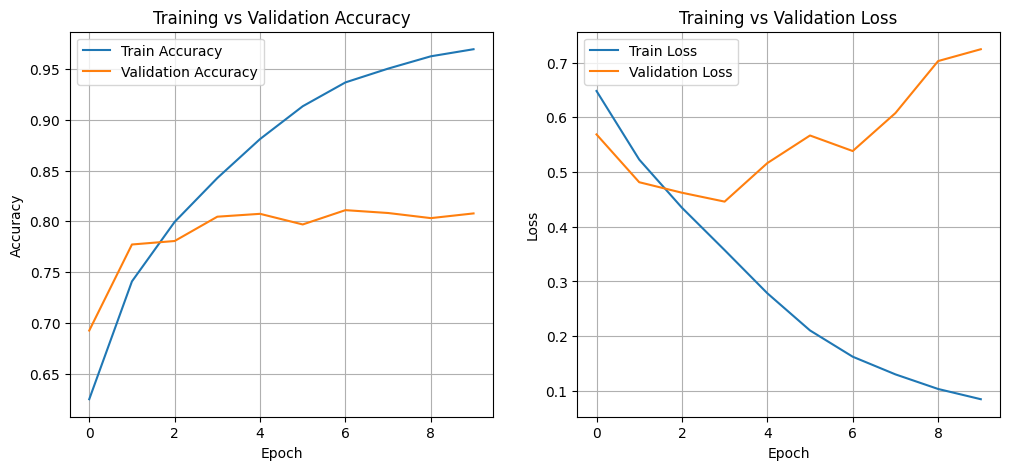

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


In [18]:
model.save("/content/cats_dogs_model.h5")
print("Model saved ✅")


Model saved ✅


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
Prediction: DOG 🐶


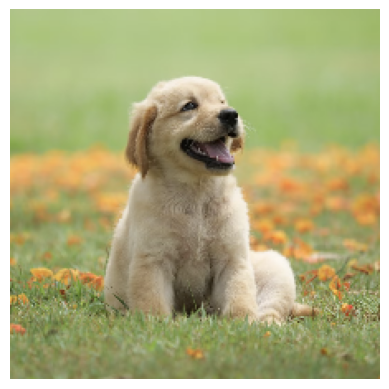

In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "/content/Screenshot 2026-02-17 at 12.53.52 PM.png"   # change filename
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")

if pred > 0.5:
    print("Prediction: DOG 🐶")
else:
    print("Prediction: CAT 🐱")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: CAT 🐱


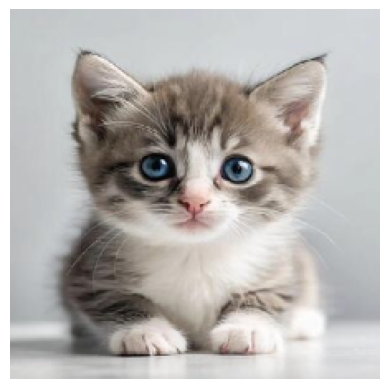

In [21]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = "/content/Screenshot 2026-02-17 at 12.54.52 PM.png"   # change filename
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]

plt.imshow(img)
plt.axis("off")

if pred > 0.5:
    print("Prediction: DOG 🐶")
else:
    print("Prediction: CAT 🐱")


In [22]:
model.save("cat_vs_dog_model.h5")


In [23]:
from google.colab import files
files.download("cat_vs_dog_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
pip install streamlit tensorflow pillow numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 44.5 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.0
    Uninstalling cachetools-7.0.0:
      Successfully uninstalled cachetools-7.0.0
